# arches_era5
In this notebook we build the arches specific era5 subset to improve data pipeline.

In [1]:
cd ..

/Users/alain/Desktop/master-thesis/guiding-generative-probabilistic-weather-models


In [2]:
import xarray as xr
from src.utils.dataset_utils import *
from src.utils.read_write import get_xr_dataset
import matplotlib.pyplot as plt
from src.dimensions import VARIABLES_DICT
from src.paths import ERA5

DATA path: /Users/alain/switchdrive
DATA path: /Users/alain/switchdrive


In [ ]:
# NOTE: moved to read_write
# def get_xr_ds():
#     timesteps = ["0", "6", "12", "18"]
#     filepath = "era5_240_2020_{}h.nc"

#     ds = xr.concat(
#         [xr.open_dataset(Path(ERA5, filepath.format(t)), engine="netcdf4") for t in timesteps],
#         dim="time",
#         data_vars="minimal",
#         coords="minimal",
#         compat="override",
#         join="exact",
#     )

#     all_vars = VARIABLES_DICT["surface"] + VARIABLES_DICT["level"]
#     ds = ds[[v for v in ds.data_vars if v in all_vars]]

#     ds = ds.sortby("time")

#     if ds.latitude[0] < ds.latitude[-1]:
#         ds = ds.reindex(latitude=ds.latitude[::-1])

#     ds = ds.roll(longitude=ds.sizes["longitude"] // 2, roll_coords=False)

#     return ds.transpose(..., "level", "latitude", "longitude")

In [ ]:
ds = get_xr_dataset()

In [8]:
print(f"{ds.nbytes / 1_000_000_000:.2f} GB")

13.94 GB


In [ ]:
def save_arches_specific_v(ds: xr.Dataset):
    path = ERA5 / "arches_era5.nc"
    ds.to_netcdf(path)

# save_arches_specific_v(ds)

## test xarray vs. tdict alignment

2020-01-08T18:00:00.000000000


4it [00:00, 77.30it/s]

start time 2019-12-31T00:00:00
ts_td 2020-01-08 18:00:00
diff:  0.0



/var/folders/05/z6mtxwt90_7_xdbfz4zyq8j80000gn/T/ipykernel_57064/3045438652.py:30: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  diff = first_slice - np.array(first_slice_td)


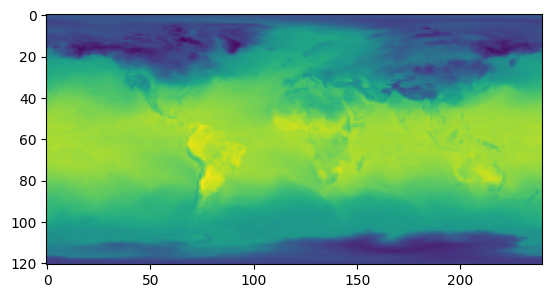

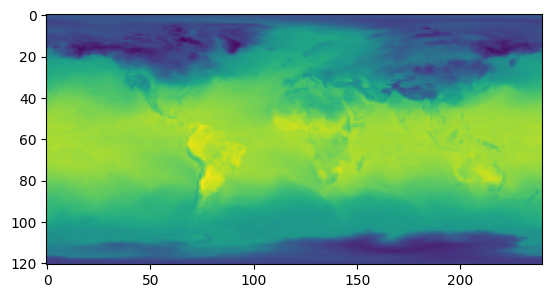

In [17]:
from src.utils.read_write import *
from src.utils.converters import tensor_timestamp_to_string

timestamp = "2020-01-08 18:00:00"
timestamp = np.datetime64(timestamp, "ns")
print(timestamp)

ds_td = get_td_dataset()
ds_timestamps = [
    np.datetime64(ts[2], "ns")
    for ts in ds_td.timestamps
]
# print(ds_timestamps)
idx_td = ds_timestamps.index(timestamp)
freq=4
x_cond_td = ds_td[idx_td-freq]

first_slice_td = ds_td.denormalize(x_cond_td)
ts_td = tensor_timestamp_to_string(x_cond_td["timestamp"])
print("ts_td", ts_td)
first_slice_td = first_slice_td["state"]["surface"][2].squeeze()

FREQ = 4
# xr dataset
# TODO: do not enable to select the first and last 4 
ds_xr = get_arches_era5()
first_slice = ds_xr["2m_temperature"].sel(time=timestamp)

# diff check
diff = first_slice - np.array(first_slice_td)
print("diff: ", diff.sum().item())

plt.figure()
plt.imshow(first_slice)
plt.show()

plt.figure()
plt.imshow(first_slice_td)
plt.show()

In [10]:
ds = get_arches_era5()